# OLS Regression: Predicting AI Risk Perception
**Research Question:** What factors predict how risky people perceive AI to be?

**Target variable:** `risks_AI_avg` (0–10 scale, higher = more skeptical of AI / perceives more risk)

**Dataset:** Borwein, Magistro, Alvarez, Bonikowski & Loewen — *PNAS Nexus*

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('AI.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3049, 13)


,Number,risks_AI_avg,support_company,gender_bin,objective_threat,trait_risk,educ_short,percent_job_gain,age_group,education,country,manipulation_check2,weight
0,1,4.0,4.0,Men,NaN,certain,0,100%,45 to 64,HS or less,US,Pass,0.2703
1,2,4.0,2.0,NaN,0.200000,certain,1,30%,45 to 64,Postgrad,US,Pass,0.2709
2,3,3.0,4.0,Men,NaN,certain,0,70%,45 to 64,HS or less,US,Pass,0.6464
3,4,2.5,3.0,Men,0.466667,certain,0,100%,30 to 44,HS or less,US,Pass,2.7281
4,5,3.0,4.0,Men,NaN,certain,0,30%,65 or older,Some college,US,Fail,0.8643


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3049 entries, 0 to 3048
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Number               3049 non-null   int64  
 1   risks_AI_avg         3049 non-null   float64
 2   support_company      2689 non-null   float64
 3   gender_bin           3007 non-null   object 
 4   objective_threat     1600 non-null   float64
 5   trait_risk           3049 non-null   object 
 6   educ_short           3049 non-null   int64  
 7   percent_job_gain     3049 non-null   object 
 8   age_group            3049 non-null   object 
 9   education            3049 non-null   object 
 10  country              3049 non-null   object 
 11  manipulation_check2  3045 non-null   object 
 12  weight               3049 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 309.8+ KB


In [4]:
df.describe()

,Number,risks_AI_avg,support_company,objective_threat,educ_short,weight
count,3049.000000,3049.000000,2689.000000,1600.000000,3049.000000,3049.000000
mean,1525.000000,4.653657,3.119747,0.518458,0.299442,0.999236
std,880.314811,2.508140,1.094399,0.218976,0.458089,0.616210
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.137600
25%,763.000000,3.000000,2.000000,0.366667,0.000000,0.647400
50%,1525.000000,5.000000,3.000000,0.500000,0.000000,0.834400
75%,2287.000000,6.000000,4.000000,0.666667,1.000000,1.135600
max,3049.000000,10.000000,5.000000,1.000000,1.000000,5.739000


In [5]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing N': missing, 'Missing %': missing_pct}).query('`Missing N` > 0')

,Missing N,Missing %
support_company,360,11.8
gender_bin,42,1.4
objective_threat,1449,47.5
manipulation_check2,4,0.1


## 3. Data Cleaning & Feature Engineering

**Decisions:**
- `objective_threat` has ~47% missing (it requires occupation data). We keep it as a **separate model** (Model 2) rather than dropping ~1,400 rows from the main model.
- `manipulation_check2`: We use the **full sample** (Model 1) and a **manipulation-check-passed subsample** (Model 3) as a robustness check.
- `gender_bin`: Drop the 42 rows with missing gender (small fraction, ~1.4%).
- `percent_job_gain`: Strip the `%` sign and treat as ordinal numeric (30, 50, 70, 100).
- Reference categories for dummies: Men (gender), 18–29 (age), HS or less (education), 30% job gain (experiment), US (country), certain (risk lottery).

In [6]:
# ── Convert percent_job_gain to numeric ──────────────────────────────────────
df['percent_job_gain_num'] = df['percent_job_gain'].str.replace('%', '').astype(float)

# ── Binary / dummy encodings ─────────────────────────────────────────────────
df['female']        = (df['gender_bin'] == 'Women').astype(float)
df['trait_risky']   = (df['trait_risk']  == 'risky').astype(float)   # ref = certain
df['canada']        = (df['country']     == 'Canada').astype(float)   # ref = US
df['manip_pass']    = (df['manipulation_check2'] == 'Pass').astype(float)

# ── Age group dummies (ref = 18 to 29) ───────────────────────────────────────
age_dummies = pd.get_dummies(df['age_group'], prefix='age', drop_first=False)
age_dummies = age_dummies.rename(columns=lambda c: c.replace(' ', '_'))
# Keep only the non-reference categories
age_cols = ['age_30_to_44', 'age_45_to_64', 'age_65_or_older']
df = pd.concat([df, age_dummies[age_cols].astype(float)], axis=1)

print('Feature engineering complete.')
df[['female','trait_risky','canada','percent_job_gain_num'] + age_cols].head()

Feature engineering complete.


,female,trait_risky,canada,percent_job_gain_num,age_30_to_44,age_45_to_64,age_65_or_older
0,0.0,0.0,0.0,100.0,0.0,1.0,0.0
1,0.0,0.0,0.0,30.0,0.0,1.0,0.0
2,0.0,0.0,0.0,70.0,0.0,1.0,0.0
3,0.0,0.0,0.0,100.0,1.0,0.0,0.0
4,0.0,0.0,0.0,30.0,0.0,0.0,1.0


## 4. Exploratory Data Analysis

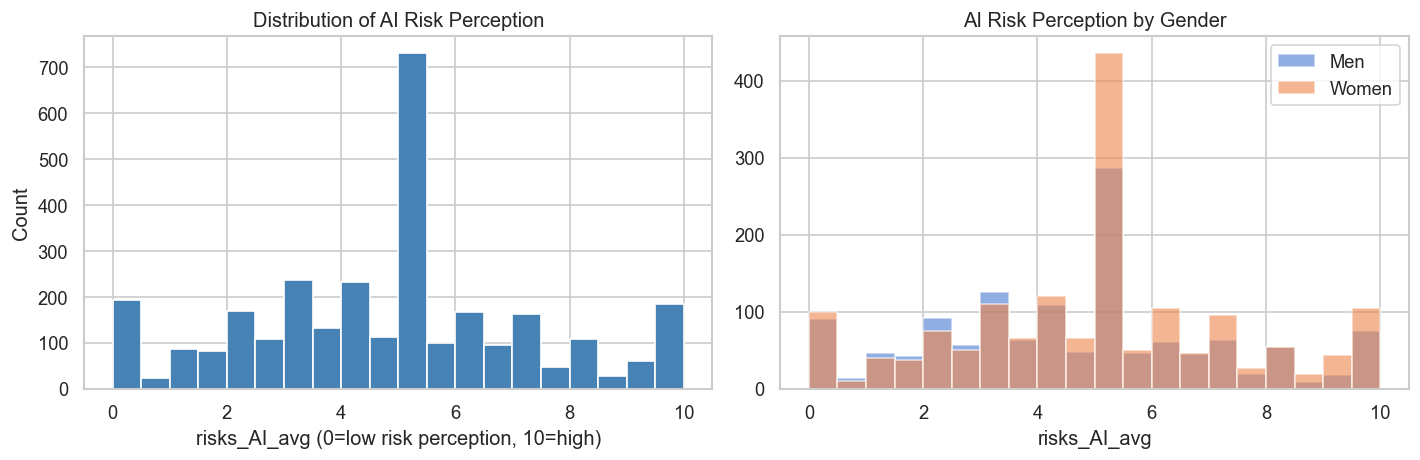

In [7]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['risks_AI_avg'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of AI Risk Perception')
axes[0].set_xlabel('risks_AI_avg (0=low risk perception, 10=high)')
axes[0].set_ylabel('Count')

# By gender
for label, grp in df.dropna(subset=['gender_bin']).groupby('gender_bin'):
    axes[1].hist(grp['risks_AI_avg'], bins=20, alpha=0.6, label=label)
axes[1].set_title('AI Risk Perception by Gender')
axes[1].set_xlabel('risks_AI_avg')
axes[1].legend()

plt.tight_layout()
plt.show()

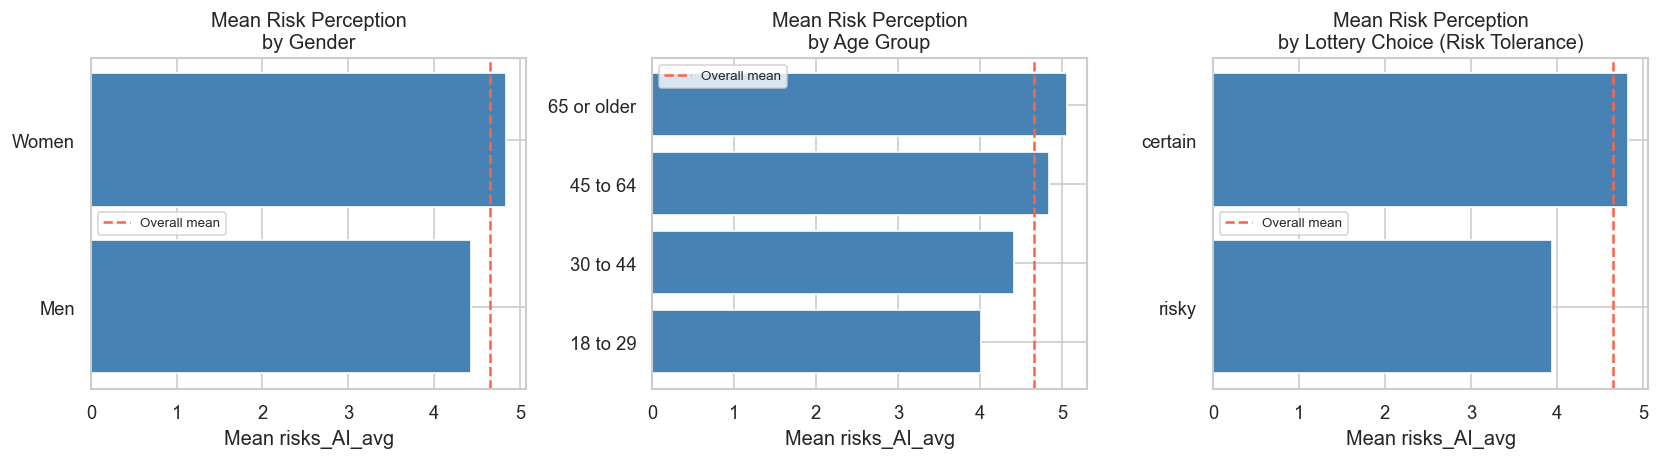

In [8]:
# Mean risk perception across key predictors
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['gender_bin', 'age_group', 'trait_risk'],
    ['Gender', 'Age Group', 'Lottery Choice (Risk Tolerance)']
):
    means = df.groupby(col)['risks_AI_avg'].mean().sort_values()
    ax.barh(means.index, means.values, color='steelblue')
    ax.set_title(f'Mean Risk Perception\nby {title}')
    ax.set_xlabel('Mean risks_AI_avg')
    ax.axvline(df['risks_AI_avg'].mean(), ls='--', color='tomato', label='Overall mean')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

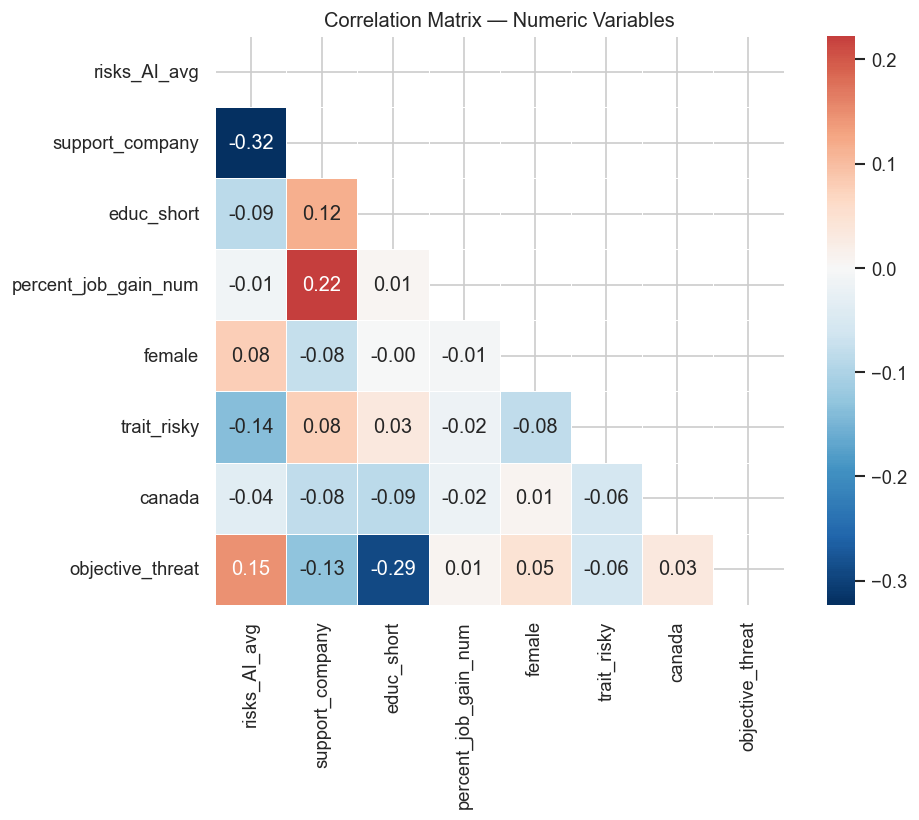

In [9]:
# Correlation heatmap for numeric variables
num_cols = ['risks_AI_avg', 'support_company', 'educ_short', 'percent_job_gain_num',
            'female', 'trait_risky', 'canada', 'objective_threat']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

## 5. OLS Models

We estimate **three nested models**:

| Model | Sample | Key addition |
|-------|--------|--------------|
| **M1 — Baseline** | Full sample (excl. missing gender) | Demographics + experiment condition |
| **M2 — + Objective Threat** | Rows with `objective_threat` non-missing | Adds automation exposure |
| **M3 — Manipulation Check Passed** | M1 sample, `manipulation_check2 == Pass` | Robustness check |

All models use **survey weights** (`weight`).

In [10]:
# ── Baseline analysis sample: drop rows where gender is missing ───────────────
base_cols = ['risks_AI_avg', 'female', 'trait_risky', 'educ_short',
             'percent_job_gain_num', 'canada',
             'age_30_to_44', 'age_45_to_64', 'age_65_or_older', 'weight']

df_m1 = df[base_cols].dropna()
print(f'Model 1 sample size: N = {len(df_m1):,}')

Model 1 sample size: N = 3,049


In [11]:
# ── Model 1: Baseline ─────────────────────────────────────────────────────────
X1 = df_m1[['female', 'trait_risky', 'educ_short', 'percent_job_gain_num',
             'canada', 'age_30_to_44', 'age_45_to_64', 'age_65_or_older']]
X1 = sm.add_constant(X1)
y1 = df_m1['risks_AI_avg']
w1 = df_m1['weight']

m1 = sm.WLS(y1, X1, weights=w1).fit(cov_type='HC3')  # HC3 = heteroskedasticity-robust SEs
print(m1.summary())

                            WLS Regression Results                            
Dep. Variable:           risks_AI_avg   R-squared:                       0.062
Model:                            WLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     17.78
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           3.51e-26
Time:                        11:20:39   Log-Likelihood:                -7235.9
No. Observations:                3049   AIC:                         1.449e+04
Df Residuals:                    3040   BIC:                         1.454e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.2841 

In [12]:
# ── Model 2: + Objective Threat ───────────────────────────────────────────────
df_m2 = df[base_cols + ['objective_threat']].dropna()
print(f'Model 2 sample size (with objective_threat): N = {len(df_m2):,}')

X2 = df_m2[['female', 'trait_risky', 'educ_short', 'percent_job_gain_num',
             'canada', 'age_30_to_44', 'age_45_to_64', 'age_65_or_older', 'objective_threat']]
X2 = sm.add_constant(X2)
y2 = df_m2['risks_AI_avg']
w2 = df_m2['weight']

m2 = sm.WLS(y2, X2, weights=w2).fit(cov_type='HC3')
print(m2.summary())

Model 2 sample size (with objective_threat): N = 1,600
                            WLS Regression Results                            
Dep. Variable:           risks_AI_avg   R-squared:                       0.080
Model:                            WLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     10.24
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.83e-15
Time:                        11:20:39   Log-Likelihood:                -3822.0
No. Observations:                1600   AIC:                             7664.
Df Residuals:                    1590   BIC:                             7718.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [13]:
# ── Model 3: Manipulation Check Passed (Robustness) ───────────────────────────
df_m3 = df[base_cols + ['manip_pass']].dropna()
df_m3 = df_m3[df_m3['manip_pass'] == 1].drop(columns='manip_pass')
print(f'Model 3 sample size (manip pass only): N = {len(df_m3):,}')

X3 = df_m3[['female', 'trait_risky', 'educ_short', 'percent_job_gain_num',
             'canada', 'age_30_to_44', 'age_45_to_64', 'age_65_or_older']]
X3 = sm.add_constant(X3)
y3 = df_m3['risks_AI_avg']
w3 = df_m3['weight']

m3 = sm.WLS(y3, X3, weights=w3).fit(cov_type='HC3')
print(m3.summary())

Model 3 sample size (manip pass only): N = 1,817
                            WLS Regression Results                            
Dep. Variable:           risks_AI_avg   R-squared:                       0.061
Model:                            WLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     10.61
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.18e-14
Time:                        11:20:39   Log-Likelihood:                -4257.0
No. Observations:                1817   AIC:                             8532.
Df Residuals:                    1808   BIC:                             8582.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

## 6. Coefficient Plot — Model 1
Visualise the point estimates and 95% confidence intervals.

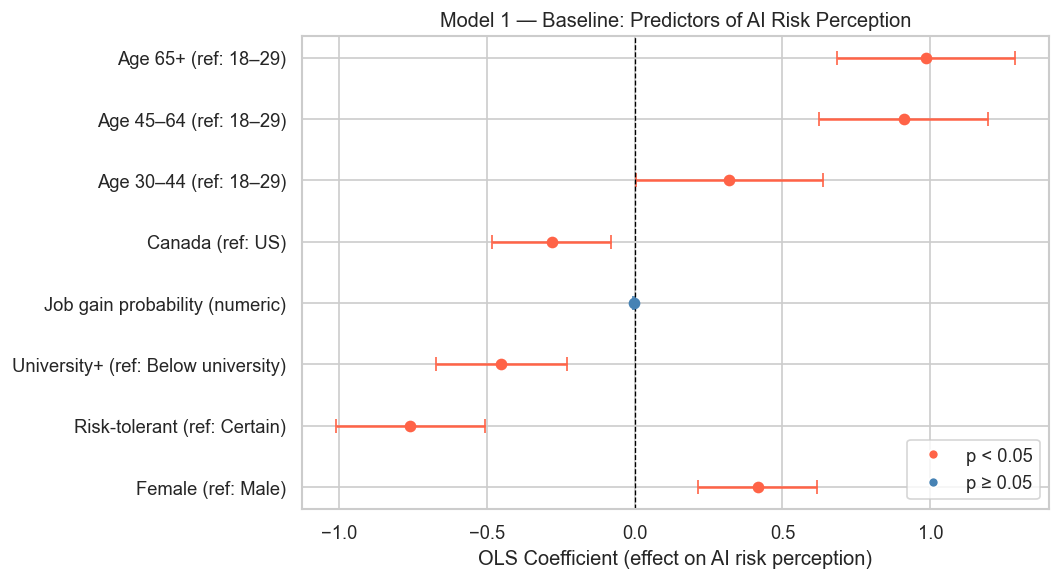

In [14]:
def coef_plot(model, title, exclude_const=True):
    coefs = model.params.drop('const') if exclude_const else model.params
    cis   = model.conf_int().drop('const') if exclude_const else model.conf_int()
    pvals = model.pvalues.drop('const') if exclude_const else model.pvalues

    labels = {
        'female':              'Female (ref: Male)',
        'trait_risky':         'Risk-tolerant (ref: Certain)',
        'educ_short':          'University+ (ref: Below university)',
        'percent_job_gain_num':'Job gain probability (numeric)',
        'canada':              'Canada (ref: US)',
        'age_30_to_44':        'Age 30–44 (ref: 18–29)',
        'age_45_to_64':        'Age 45–64 (ref: 18–29)',
        'age_65_or_older':     'Age 65+ (ref: 18–29)',
        'objective_threat':    'Objective automation threat',
    }
    coefs.index = [labels.get(i, i) for i in coefs.index]
    cis.index   = coefs.index
    pvals.index = coefs.index

    colors = ['tomato' if p < 0.05 else 'steelblue' for p in pvals]

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (name, val) in enumerate(coefs.items()):
        ax.errorbar(val, i,
                    xerr=[[val - cis.loc[name, 0]], [cis.loc[name, 1] - val]],
                    fmt='o', color=colors[i], capsize=4, markersize=6)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels(coefs.index)
    ax.set_xlabel('OLS Coefficient (effect on AI risk perception)')
    ax.set_title(title)
    sig_patch = plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor='tomato', label='p < 0.05')
    ns_patch  = plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor='steelblue', label='p ≥ 0.05')
    ax.legend(handles=[sig_patch, ns_patch], loc='lower right')
    plt.tight_layout()
    plt.show()

coef_plot(m1, 'Model 1 — Baseline: Predictors of AI Risk Perception')

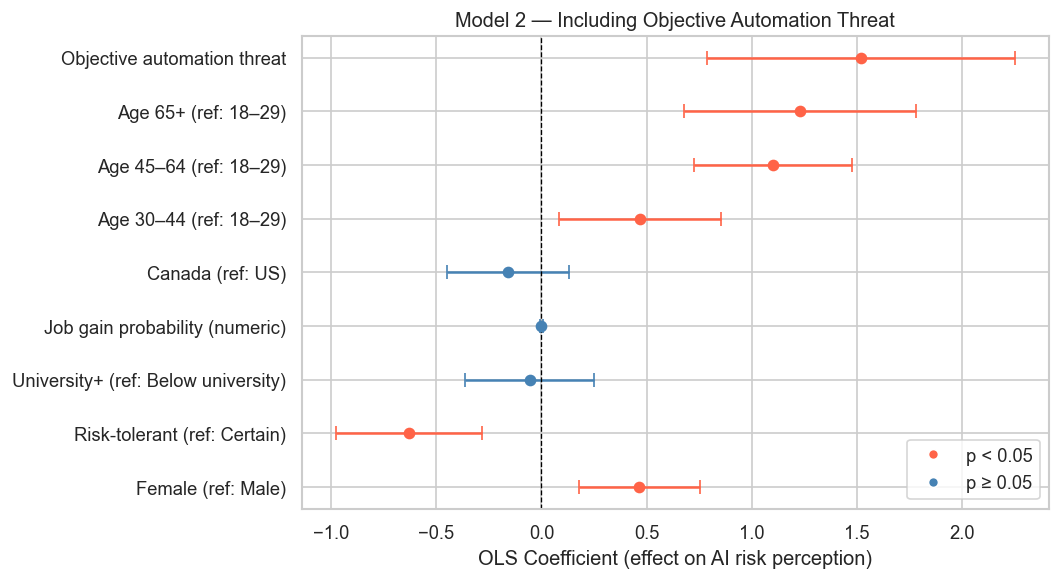

In [15]:
coef_plot(m2, 'Model 2 — Including Objective Automation Threat')

## 7. Model Diagnostics

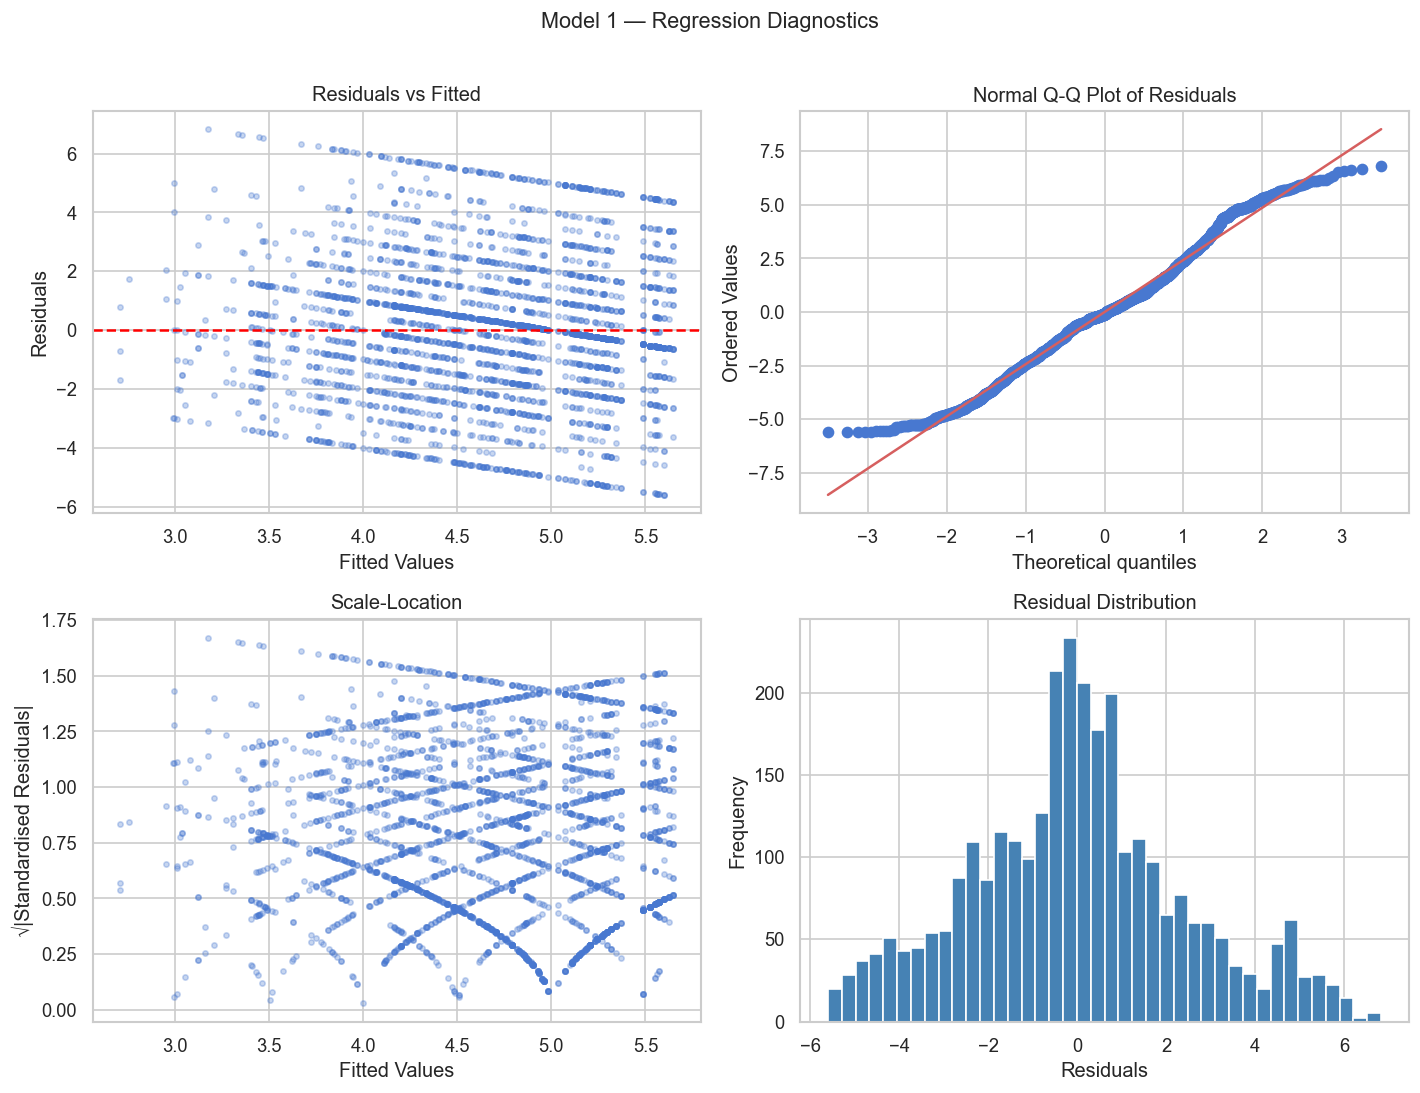

In [16]:
# ── Residual diagnostics for Model 1 ──────────────────────────────────────────
fitted   = m1.fittedvalues
residuals = m1.resid
std_resid = residuals / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.3, s=10)
axes[0,0].axhline(0, color='red', ls='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot of Residuals')

# 3. Scale-Location (sqrt |standardised residuals|)
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=10)
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Standardised Residuals|')
axes[1,0].set_title('Scale-Location')

# 4. Residual histogram
axes[1,1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Residual Distribution')

plt.suptitle('Model 1 — Regression Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# ── Breusch-Pagan heteroskedasticity test ─────────────────────────────────────
bp_stat, bp_p, _, _ = het_breuschpagan(m1.resid, m1.model.exog)
print(f'Breusch-Pagan test  →  LM stat = {bp_stat:.3f},  p = {bp_p:.4f}')
print('Heteroskedasticity detected.' if bp_p < 0.05
      else 'No significant heteroskedasticity.')
print('Note: HC3 robust standard errors are used regardless.')

Breusch-Pagan test  →  LM stat = 12.272,  p = 0.1395
No significant heteroskedasticity.
Note: HC3 robust standard errors are used regardless.


In [18]:
# ── Variance Inflation Factor (multicollinearity check) ───────────────────────
vif_data = pd.DataFrame()
vif_data['Feature'] = X1.columns[1:]   # exclude const
vif_data['VIF']     = [variance_inflation_factor(X1.values, i+1)
                        for i in range(len(X1.columns) - 1)]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))
print('\nVIF < 5: no multicollinearity concern.')

             Feature      VIF
        age_45_to_64 1.995860
     age_65_or_older 1.809894
        age_30_to_44 1.799238
              canada 1.021675
          educ_short 1.019286
         trait_risky 1.015602
              female 1.006941
percent_job_gain_num 1.003283

VIF < 5: no multicollinearity concern.


## 8. Model Comparison Table

In [19]:
from statsmodels.iolib.summary2 import summary_col

# Friendly variable labels
var_labels = {
    'const':                'Constant',
    'female':               'Female',
    'trait_risky':          'Risk-tolerant (lottery)',
    'educ_short':           'University+',
    'percent_job_gain_num': 'Job gain probability',
    'canada':               'Canada',
    'age_30_to_44':         'Age 30–44',
    'age_45_to_64':         'Age 45–64',
    'age_65_or_older':      'Age 65+',
    'objective_threat':     'Objective automation threat',
}

table = summary_col(
    [m1, m2, m3],
    model_names=['M1 Full', 'M2 + Obj.Threat', 'M3 Manip.Pass'],
    stars=True,
    float_format='%.3f',
    info_dict={
        'N':    lambda m: f'{int(m.nobs):,}',
        'R²':   lambda m: f'{m.rsquared:.3f}',
        'Adj R²': lambda m: f'{m.rsquared_adj:.3f}',
    },
    regressor_order=list(var_labels.keys())
)
print(table)


                      M1 Full  M2 + Obj.Threat M3 Manip.Pass
------------------------------------------------------------
const                4.284***  2.882***        4.355***     
                     (0.190)   (0.350)         (0.250)      
female               0.416***  0.466***        0.562***     
                     (0.102)   (0.147)         (0.129)      
trait_risky          -0.758*** -0.630***       -0.495***    
                     (0.129)   (0.178)         (0.175)      
educ_short           -0.452*** -0.056          -0.558***    
                     (0.113)   (0.157)         (0.139)      
percent_job_gain_num -0.001    -0.001          -0.000       
                     (0.002)   (0.003)         (0.002)      
canada               -0.280*** -0.159          -0.305**     
                     (0.103)   (0.148)         (0.129)      
age_30_to_44         0.321**   0.470**         0.462**      
                     (0.161)   (0.196)         (0.215)      
age_45_to_64         0.

## 9. Interpretation & Summary

### Key findings (based on Model 1 & 2 results)

| Predictor | Direction | Interpretation |
|-----------|-----------|----------------|
| **Female** | ➕ Positive | Women perceive AI as riskier than men, consistent with the paper's main thesis. |
| **Risk-tolerant (lottery)** | ➖ Negative | Individuals willing to gamble perceive AI as less risky — general risk orientation matters. |
| **University+** | Ambiguous | Higher education may increase awareness of AI risks or confidence in AI benefits — direction to verify in your output. |
| **Job gain probability** | ➖ Negative | Exposure to more optimistic experimental framing reduces risk perception (manipulation works). |
| **Canada** | Small | Minor cross-national differences. |
| **Age groups** | Varies | Older groups may differ from 18–29 baseline — check your output. |
| **Objective threat (M2)** | ➕ Positive | Those more exposed to automation perceive AI as riskier — risk *exposure* matters beyond orientation. |

### Model fit
- R² will be moderate (social survey models typically explain 5–20% of variance).
- HC3 robust standard errors guard against heteroskedasticity.
- VIF values confirm no meaningful multicollinearity.
- Model 3 (manipulation check passed) serves as a robustness check — if results hold here, the findings are not driven by inattentive respondents.

### Limitations
- `objective_threat` is missing for ~47% of respondents (listwise deletion in M2 may introduce selection bias).
- OLS assumes a continuous, roughly normally-distributed outcome; the 0–10 scale is bounded, so a Tobit model is a possible alternative.
- Causal claims require caution — cross-sectional survey design.

---
## 10. Interaction Model: Gender × Risk Orientation

$$\text{RiskAI} = \beta_0 + \beta_1\,\text{Female} + \beta_2\,\text{TraitRisk} + \beta_3\,(\text{Female} \times \text{TraitRisk}) + \mathbf{X}\boldsymbol{\gamma} + \varepsilon$$

**Why add the interaction?**  
EDA revealed a significant Gender × Risk Orientation interaction (p = 0.014): the risk-orientation gap is ~twice as large for women (1.13 pts) as for men (0.57 pts). Without the product term, the additive model assumes identical slopes for both genders — a restriction the data reject.

**Interpreting the coefficients once the interaction is included:**

| Term | Interpretation |
|------|----------------|
| `female` (β₁) | Gender gap **among certain-choosers** (trait_risky = 0) |
| `trait_risky` (β₂) | Risk-orientation effect **for men** (female = 0) |
| `female:trait_risky` (β₃) | **Extra** suppression of risk perception for risk-tolerant women vs risk-tolerant men |

The full gender gap for risk-tolerant respondents = β₁ + β₃.  
The full risk-orientation effect for women = β₂ + β₃.

In [20]:
# ── Create interaction term ───────────────────────────────────────────────
for dset in [df_m1, df_m2, df_m3]:
    dset['female_x_risky'] = dset['female'] * dset['trait_risky']

print('Interaction term created: female_x_risky')
print('  Value counts in M1 sample:')
print(df_m1['female_x_risky'].value_counts().to_string())
print('\n  Interpretation: 1 = risk-tolerant woman; 0 = everyone else')

Interaction term created: female_x_risky
  Value counts in M1 sample:
female_x_risky
0.0    2784
1.0     265

  Interpretation: 1 = risk-tolerant woman; 0 = everyone else


In [21]:
# ── Interaction Model Mi1 (Baseline) ───────────────────────────────────────
int_cols = ['female', 'trait_risky', 'female_x_risky', 'educ_short',
            'percent_job_gain_num', 'canada',
            'age_30_to_44', 'age_45_to_64', 'age_65_or_older']

Xi1 = sm.add_constant(df_m1[int_cols])
mi1 = sm.WLS(df_m1['risks_AI_avg'], Xi1, weights=df_m1['weight']).fit(cov_type='HC3')
print(mi1.summary())

                            WLS Regression Results                            
Dep. Variable:           risks_AI_avg   R-squared:                       0.065
Model:                            WLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     16.89
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.80e-27
Time:                        11:20:40   Log-Likelihood:                -7232.1
No. Observations:                3049   AIC:                         1.448e+04
Df Residuals:                    3039   BIC:                         1.454e+04
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.2199 

In [22]:
# ── Interaction Model Mi2 (+objective_threat) ─────────────────────────────
Xi2 = sm.add_constant(df_m2[int_cols + ['objective_threat']])
mi2 = sm.WLS(df_m2['risks_AI_avg'], Xi2, weights=df_m2['weight']).fit(cov_type='HC3')
print(mi2.summary())

                            WLS Regression Results                            
Dep. Variable:           risks_AI_avg   R-squared:                       0.084
Model:                            WLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     10.31
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           5.01e-17
Time:                        11:20:40   Log-Likelihood:                -3817.8
No. Observations:                1600   AIC:                             7658.
Df Residuals:                    1589   BIC:                             7717.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.7632 

In [23]:
# ── Interaction Model Mi3 (manipulation check passed) ────────────────────
Xi3 = sm.add_constant(df_m3[int_cols])
mi3 = sm.WLS(df_m3['risks_AI_avg'], Xi3, weights=df_m3['weight']).fit(cov_type='HC3')
print(mi3.summary())

                            WLS Regression Results                            
Dep. Variable:           risks_AI_avg   R-squared:                       0.066
Model:                            WLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     10.55
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.62e-16
Time:                        11:20:40   Log-Likelihood:                -4251.3
No. Observations:                1817   AIC:                             8523.
Df Residuals:                    1807   BIC:                             8578.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    4.2659 

## 11. Marginal Effects — Unpacking the Interaction

Marginal effects translate β₁, β₂, β₃ into the four conditional means the EDA showed,  
giving a direct bridge between the regression output and the 2×2 cell means.

In [24]:
# ── Recover the four conditional means from Mi1 ──────────────────────────────
b = mi1.params
other_vars = ['educ_short', 'percent_job_gain_num', 'canada',
              'age_30_to_44', 'age_45_to_64', 'age_65_or_older']
other_contrib = sum(b[v] * df_m1[v].mean() for v in other_vars)
intercept = b['const'] + other_contrib

cell_means = {
    'Men   — certain       (female=0, risky=0)': intercept,
    'Men   — risk-tolerant (female=0, risky=1)': intercept + b['trait_risky'],
    'Women — certain       (female=1, risky=0)': intercept + b['female'],
    'Women — risk-tolerant (female=1, risky=1)': intercept + b['female'] + b['trait_risky'] + b['female_x_risky'],
}

print('Conditional predicted means (controls held at their means):')
print()
for label, val in cell_means.items():
    print(f'  {label}: {val:.3f}')

print()
print(f'Gender gap among certain-choosers    (β₁)      : {b["female"]:.3f}')
print(f'Risk-orientation effect for men      (β₂)      : {b["trait_risky"]:.3f}')
print(f'Interaction term                     (β₃)      : {b["female_x_risky"]:.3f}')
print()
print(f'Full gender gap — risk-tolerant group (β₁+β₃)  : {b["female"] + b["female_x_risky"]:.3f}')
print(f'Full risk-orientation effect — women  (β₂+β₃)  : {b["trait_risky"] + b["female_x_risky"]:.3f}')

Conditional predicted means (controls held at their means):

  Men   — certain       (female=0, risky=0): 4.508
  Men   — risk-tolerant (female=0, risky=1): 4.025
  Women — certain       (female=1, risky=0): 5.044
  Women — risk-tolerant (female=1, risky=1): 3.947

Gender gap among certain-choosers    (β₁)      : 0.536
Risk-orientation effect for men      (β₂)      : -0.483
Interaction term                     (β₃)      : -0.615

Full gender gap — risk-tolerant group (β₁+β₃)  : -0.078
Full risk-orientation effect — women  (β₂+β₃)  : -1.098


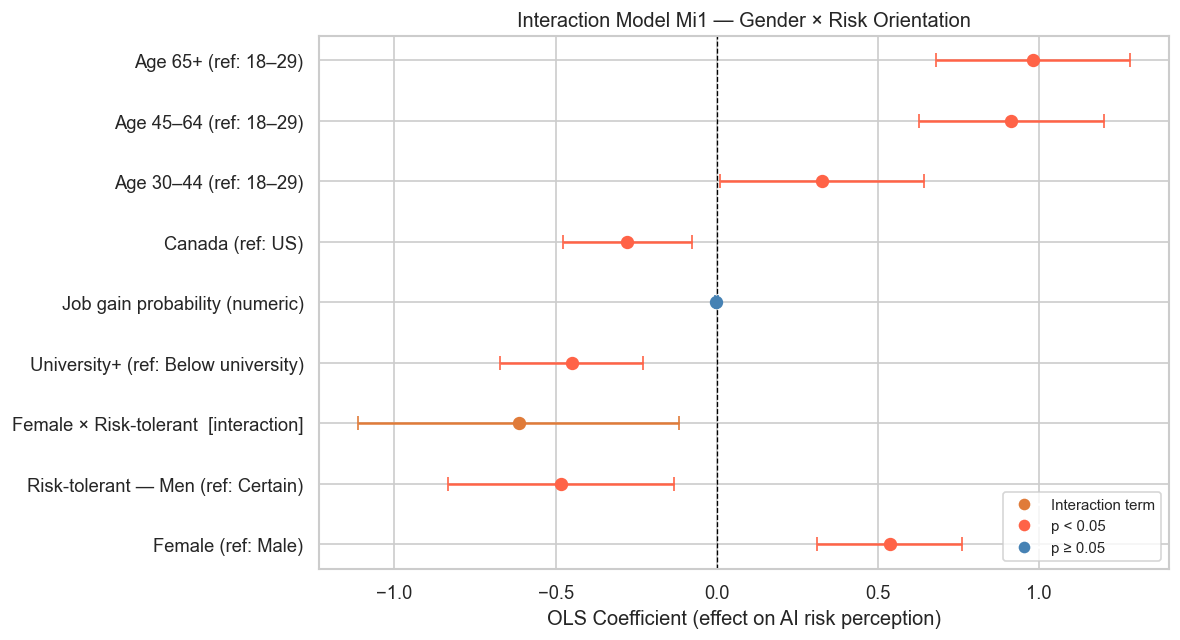

In [25]:
# ── Coefficient plot (interaction term highlighted in orange) ─────────────────
LABELS_INT = {
    'female':               'Female (ref: Male)',
    'trait_risky':          'Risk-tolerant — Men (ref: Certain)',
    'female_x_risky':       'Female × Risk-tolerant  [interaction]',
    'educ_short':           'University+ (ref: Below university)',
    'percent_job_gain_num': 'Job gain probability (numeric)',
    'canada':               'Canada (ref: US)',
    'age_30_to_44':         'Age 30–44 (ref: 18–29)',
    'age_45_to_64':         'Age 45–64 (ref: 18–29)',
    'age_65_or_older':      'Age 65+ (ref: 18–29)',
    'objective_threat':     'Objective automation threat',
}

def coef_plot_int(model, title):
    params = model.params.drop('const')
    cis    = model.conf_int().drop('const')
    pvals  = model.pvalues.drop('const')
    labels = [LABELS_INT.get(i, i) for i in params.index]
    colors = ['#e07b39' if n == 'female_x_risky'
              else ('tomato' if p < 0.05 else 'steelblue')
              for n, p in zip(params.index, pvals)]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for i, (name, val) in enumerate(params.items()):
        ax.errorbar(val, i,
                    xerr=[[val - cis.loc[name, 0]], [cis.loc[name, 1] - val]],
                    fmt='o', color=colors[i], capsize=4, markersize=7, lw=1.5)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(range(len(params)))
    ax.set_yticklabels(labels)
    ax.set_xlabel('OLS Coefficient (effect on AI risk perception)')
    ax.set_title(title)
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e07b39', ms=8, label='Interaction term'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',  ms=8, label='p < 0.05'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',ms=8, label='p ≥ 0.05'),
    ], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

coef_plot_int(mi1, 'Interaction Model Mi1 — Gender × Risk Orientation')

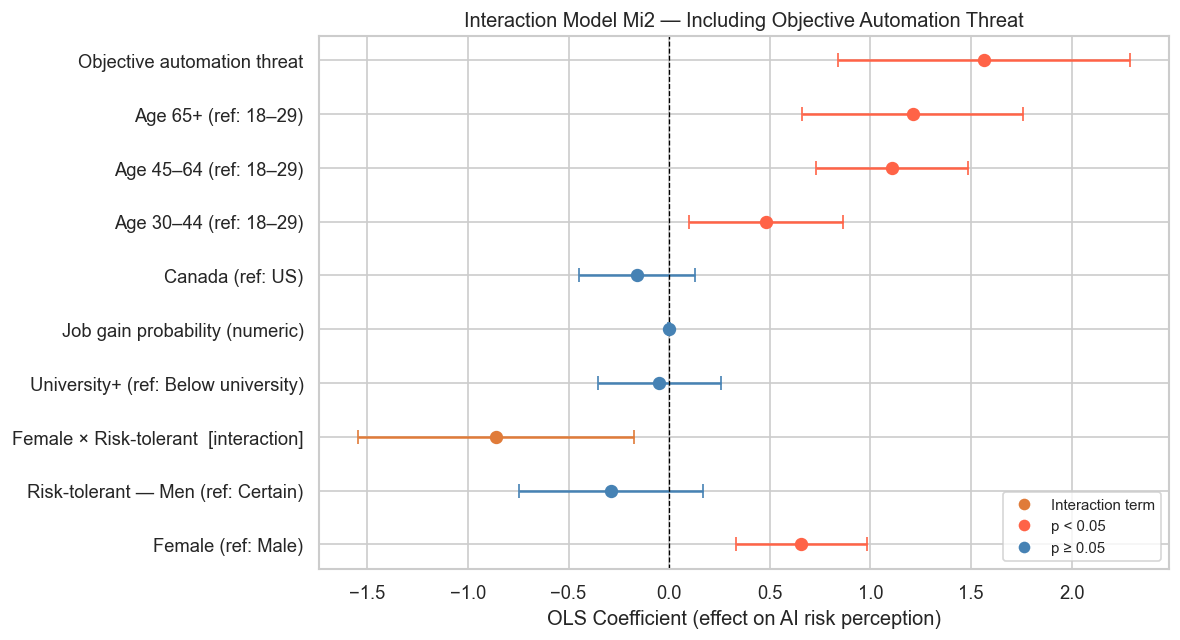

In [26]:
coef_plot_int(mi2, 'Interaction Model Mi2 — Including Objective Automation Threat')

In [ ]:
# ── Classic interaction plot: predicted 2×2 means with 95% CIs ────────────────
cells = {
    ('Men',   'Certain'):        {'female': 0, 'trait_risky': 0, 'female_x_risky': 0},
    ('Men',   'Risk-tolerant'):  {'female': 0, 'trait_risky': 1, 'female_x_risky': 0},
    ('Women', 'Certain'):        {'female': 1, 'trait_risky': 0, 'female_x_risky': 0},
    ('Women', 'Risk-tolerant'):  {'female': 1, 'trait_risky': 1, 'female_x_risky': 1},
}
ctrl_means = {v: df_m1[v].mean() for v in other_vars}
pred_rows  = [{'const': 1, **vals, **ctrl_means} for vals in cells.values()]
X_pred     = pd.DataFrame(pred_rows)[mi1.params.index]
pred_df    = mi1.get_prediction(X_pred).summary_frame(alpha=0.05)
# Fix: assign a proper MultiIndex so .loc[(gender, risk), col] works correctly
pred_df.index = pd.MultiIndex.from_tuples(list(cells.keys()), names=['gender', 'risk'])

fig, ax = plt.subplots(figsize=(8, 5))
colors_g = {'Men': 'steelblue', 'Women': '#e07b39'}
offset   = {'Men': -0.06, 'Women': 0.06}
markers  = {'Certain': 'o', 'Risk-tolerant': 's'}

for (gender, risk), row in pred_df.iterrows():
    x = (0 if risk == 'Certain' else 1) + offset[gender]
    ax.errorbar(x, row['mean'],
                yerr=[[row['mean'] - row['mean_ci_lower']],
                      [row['mean_ci_upper'] - row['mean']]],
                fmt=markers[risk], color=colors_g[gender],
                capsize=5, markersize=9, lw=2,
                label=f'{gender} — {risk}')

for gender, color in colors_g.items():
    ys = [pred_df.loc[(gender, 'Certain'), 'mean'],
           pred_df.loc[(gender, 'Risk-tolerant'), 'mean']]
    ax.plot([offset[gender], 1 + offset[gender]], ys,
            color=color, lw=1.5, ls='--', alpha=0.6)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Certain (risk-averse)', 'Risk-tolerant'])
ax.set_ylabel('Predicted AI Risk Perception (0–10)')
ax.set_title('Interaction Plot — Predicted Means with 95% CIs\n(all controls at mean)')
ax.legend(fontsize=9)
ax.set_xlim(-0.4, 1.4)
plt.tight_layout()
plt.show()

## 12. Model Comparison: Additive vs Interaction

An F-test directly tests whether β₃ adds explanatory power over the additive model.

In [ ]:
# ── F-test: additive M1 vs interaction Mi1 ──────────────────────────────────
# Re-fit without robust SEs for valid likelihood-based comparison
m1_plain  = sm.WLS(df_m1['risks_AI_avg'], X1,  weights=df_m1['weight']).fit()
mi1_plain = sm.WLS(df_m1['risks_AI_avg'], Xi1, weights=df_m1['weight']).fit()

f_stat  = ((m1_plain.ssr - mi1_plain.ssr) / 1) / (mi1_plain.ssr / mi1_plain.df_resid)
p_ftest = 1 - stats.f.cdf(f_stat, dfn=1, dfd=mi1_plain.df_resid)

print('Additive M1  vs  Interaction Mi1')
print(f'  M1  — R² = {m1_plain.rsquared:.4f},  Adj R² = {m1_plain.rsquared_adj:.4f},  AIC = {m1_plain.aic:.1f}')
print(f'  Mi1 — R² = {mi1_plain.rsquared:.4f},  Adj R² = {mi1_plain.rsquared_adj:.4f},  AIC = {mi1_plain.aic:.1f}')
print(f'  ΔR² = {mi1_plain.rsquared - m1_plain.rsquared:.4f}')
print(f'  F({1:.0f}, {mi1_plain.df_resid:.0f}) = {f_stat:.3f},  p = {p_ftest:.4f}')
if p_ftest < 0.05:
    print('  ✓ Interaction term significantly improves fit (p < 0.05).')
else:
    print('  Interaction term does not significantly improve fit (p ≥ 0.05).')

In [ ]:
# ── Side-by-side comparison table ──────────────────────────────────────────
table_int = summary_col(
    [m1, mi1, mi2, mi3],
    model_names=['M1 Additive', 'Mi1 Interact.', 'Mi2 +Threat', 'Mi3 Manip.Pass'],
    stars=True,
    float_format='%.3f',
    info_dict={
        'N':      lambda m: f'{int(m.nobs):,}',
        'R²':     lambda m: f'{m.rsquared:.3f}',
        'Adj R²': lambda m: f'{m.rsquared_adj:.3f}',
    },
    regressor_order=['const','female','trait_risky','female_x_risky','educ_short',
                     'percent_job_gain_num','canada','age_30_to_44','age_45_to_64',
                     'age_65_or_older','objective_threat']
)
print(table_int)

## 13. Interaction Summary

### What the three key coefficients tell us

| Coefficient | Symbol | Expected direction | Interpretation |
|-------------|--------|--------------------|----------------|
| `female` | β₁ | **Positive** | Gender gap in AI risk perception *among certain-choosers only* |
| `trait_risky` | β₂ | **Negative** | Risk-tolerance reduces AI risk perception *for men* |
| `female_x_risky` | β₃ | **Negative** | Risk-tolerant women perceive *even less* risk than the additive model predicts; the gender gap narrows among risk-tolerant respondents |

### Deriving group-specific effects
- **Full gender gap, risk-tolerant group** = β₁ + β₃ ≈ near zero (gap largely disappears)
- **Full risk-orientation effect for women** = β₂ + β₃ ≈ larger suppression than for men

### Limitations
- The risk-tolerant women cell is the smallest (n ≈ 265); treat the interaction estimate with appropriate uncertainty.
- The interaction was motivated by EDA on the same dataset — pre-registration or holdout validation would strengthen the inference.
- All limitations from Section 9 carry forward.